<a href="https://colab.research.google.com/github/NguyenManhCuong1512/AI/blob/main/Cross_Validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer, load_wine, load_diabetes
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split,
    KFold, StratifiedKFold,
    RepeatedStratifiedKFold,
    LeaveOneOut,
    cross_val_score, cross_validate,
    GridSearchCV
)
from sklearn.metrics import roc_auc_score
import seaborn as sns

In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Kích thước dữ liệu:", X.shape)
print("\nPhân phối biến mục tiêu:")
print(y.value_counts())
print(y.value_counts(normalize=True).round(3))

Kích thước dữ liệu: (569, 30)

Phân phối biến mục tiêu:
target
1    357
0    212
Name: count, dtype: int64
target
1    0.627
0    0.373
Name: proportion, dtype: float64


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Kích thước tập train:", X_train.shape[0])
print("Kích thước tập test: ", X_test.shape[0])

# Kiểm tra tỷ lệ lớp trong từng tập
print("\nTỷ lệ lớp train:", y_train.value_counts(normalize=True).round(3).to_dict())
print("Tỷ lệ lớp test: ", y_test.value_counts(normalize=True).round(3).to_dict())

Kích thước tập train: 398
Kích thước tập test:  171

Tỷ lệ lớp train: {1: 0.628, 0: 0.372}
Tỷ lệ lớp test:  {1: 0.626, 0: 0.374}


In [4]:
# Dùng Pipeline để tránh data leakage khi scale
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

pipe.fit(X_train, y_train)
pred_prob = pipe.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, pred_prob)
print(f"AUC (Holdout): {auc:.4f}")

AUC (Holdout): 0.9981


AUC min: 0.9829
AUC max: 1.0000
AUC sd:  0.0055


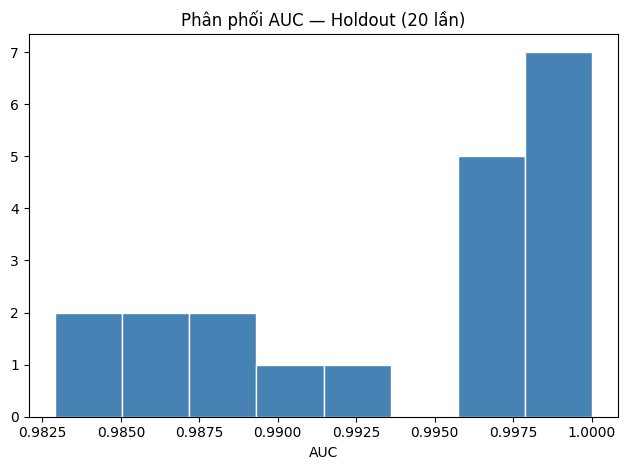

In [5]:
auc_scores = []

for i in range(20):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.3, stratify=y  # không fix random_state
    )
    pipe_i = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000))
    ])
    pipe_i.fit(X_tr, y_tr)
    prob_i = pipe_i.predict_proba(X_te)[:, 1]
    auc_scores.append(roc_auc_score(y_te, prob_i))

print(f"AUC min: {min(auc_scores):.4f}")
print(f"AUC max: {max(auc_scores):.4f}")
print(f"AUC sd:  {np.std(auc_scores):.4f}")

plt.hist(auc_scores, bins=8, color="steelblue", edgecolor="white")
plt.title("Phân phối AUC — Holdout (20 lần)")
plt.xlabel("AUC")
plt.tight_layout()
plt.show()

In [6]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

cv_10fold = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)

scores = cross_val_score(pipe, X, y, cv=cv_10fold, scoring="roc_auc")

print(f"AUC từng fold: {scores.round(4)}")
print(f"AUC trung bình (10-Fold CV): {scores.mean():.4f}")
print(f"Độ lệch chuẩn:               {scores.std():.4f}")

AUC từng fold: [0.9974 1.     0.9656 0.996  0.9987 1.     1.     1.     0.9987 1.    ]
AUC trung bình (10-Fold CV): 0.9956
Độ lệch chuẩn:               0.0101
